# CapWGS CNV benchmark vs. public single-cell WGA methods

Two per-cell metrics, all on 1Mb bins, all computed after masking centromere/heterochromatin regions defined from the matched bulk:

1. **Discordant bins (FDR proxy)** — fraction of bins whose AneuFinder copy-number state lies outside ±1 of the cell's dominant CN.
2. **Within-method pairwise MAPD (precision)** — median absolute difference between smoothed log2 tracks of same-donor / same-method cell pairs.

Donors: CD34 (PTA), BJ_fib (LIANTI / MDA / MALBAC / DOP-PCR), B_lymph (PTA / MDA), HSC4 (CapWGS: mMDA / PTA / Cell Growth).

Each metric is shown in two splits: CapWGS sub-methods (mMDA / PTA / Cell Growth, HSC4 only) and CapWGS vs well-based methods (PTA / LIANTI / MDA / MALBAC / CapWGS).

The bulks are *not* used as CN-state truth — AneuFinder is miscalibrated at full bulk depth (CD34 bulk: all segments CN=0; BJ_fib bulks: bimodal noise). They are used only as a coverage-shape reference and a centromere/heterochromatin mask. Donors are presumed-normal tissue, so any non-baseline CN call outside the mask is treated as a false positive.

In [1]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_context('notebook')

pal = [
    "#FF1B5E", "#FFDB57", "#438CFD", "#FF8C00", "#80F15E",
    "#03FFFF", "#5941A9", "#E980FC", "#1A1A2E", "#F5F0FF", "#C17F3E",
]

pub_pal = {
    "Bulk": pal[2],
    "PTA": pal[4],
    "MDA": pal[0],
    "mMDA": pal[0],
    "LIANTI": pal[3],
    "MALBAC": pal[1],
    "CapWGS": pal[6],
    "Cell Growth": pal[6],
    "DOP_PCR": pal[5],
}

ROOT = Path('..').resolve()
COMP = ROOT / 'data/benchmarking/cnv/_compiled'

qc = pd.read_csv(COMP / 'cnv_qc.tsv', sep='\t')
segs = pd.read_csv(COMP / 'cnv_segments.tsv', sep='\t')
cap = pd.read_csv(ROOT / 'results/benchmarking/cap_data.csv')

def group_method(m):
    if pd.isna(m): return m
    if m.startswith('MDA'): return 'MDA'
    if m.startswith('MALBAC'): return 'MALBAC'
    return m

qc['wga_method'] = qc['method'].map(group_method)
segs['wga_method'] = segs['method_y'].map(group_method) if 'method_y' in segs.columns else segs['method'].map(group_method)

cells = qc[qc['sample_type'] == 'cell'].copy()

def load_bins(donor, sample):
    f = ROOT / f'data/benchmarking/cnv/{donor}/{sample}.bins.tsv.gz'
    return pd.read_csv(f, sep='\t')

order_cap = ["mMDA", "PTA", "Cell Growth"]
order_pub = ["PTA", "LIANTI", "MDA", "MALBAC", "CapWGS"]

print('Cells:', len(cells), '— by method:')
print(cells['wga_method'].value_counts().to_string())

Cells: 144 — by method:
wga_method
CapWGS     50
PTA        39
LIANTI     30
MDA        16
MALBAC      6
DOP_PCR     3


## Bulk vs. single-cell coverage tracks (PTA paper Fig 2 style)

Stacked genome-wide normalized bin-count tracks: bulk on top (treated as ground-truth coverage shape), then a few single cells below. We're plotting *raw* bin counts (`counts` from AneuFinder `binReads`, normalized to the per-sample median), not AneuFinder CN calls — the bulk AneuFinder calls are unreliable (HMM mis-calibrated for deep coverage), but the underlying bin-count signal is fine.

For each cell, the same large-scale step pattern visible in the bulk should be visible (though noisier). Where the cell track diverges from the bulk in a focal region, that's likely a false positive CNV from WGA.


In [2]:
import matplotlib as mpl
mpl.rcParams.update(
    {
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["TeX Gyre Heros"],
        "font.size": 16,
        # Axes lines
        "axes.linewidth": 2,
        # Tick marks
        "xtick.major.width": 2,
        "ytick.major.width": 2,
        "xtick.minor.width": 2,
        "ytick.minor.width": 2,
        # Tick direction (outward is common in publications)
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

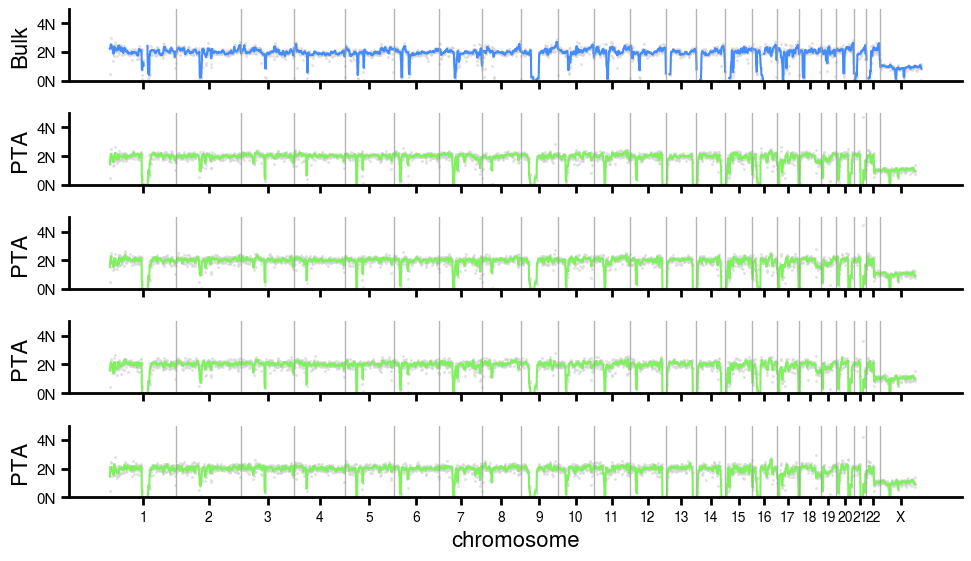

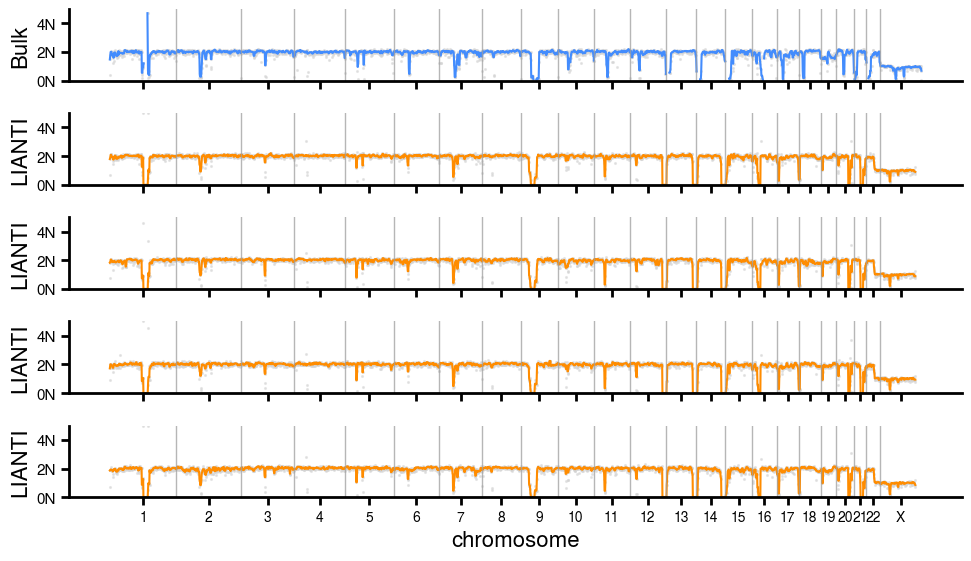

mMDA: CAACTTGCAGGAAG pct_1x=0.480
PTA: AAGGCTTGAGGAAG pct_1x=0.526
Cell Growth: CGGTAGAAAGGACT pct_1x=0.675


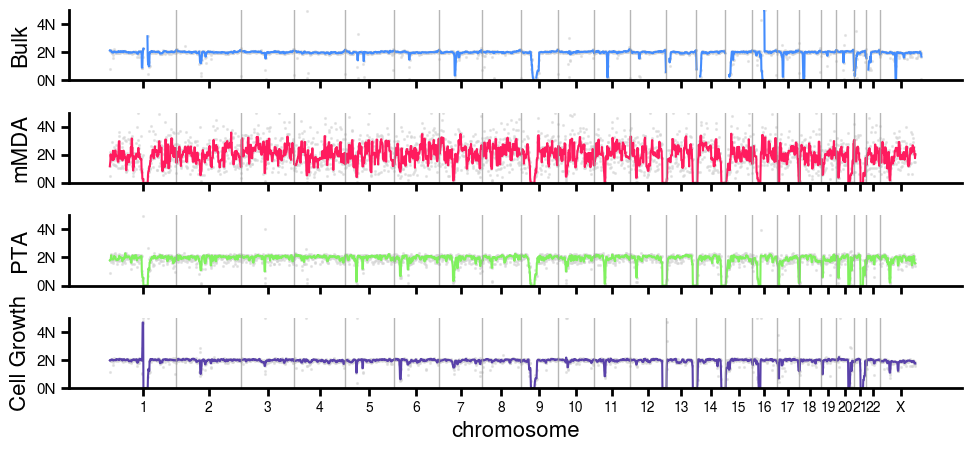

In [3]:
# Bulk + cells coverage-track plot, per donor with a bulk
# All tracks use 1Mb-bin normalized coverage. Bulks: deepTools bamCoverage bigWigs.
# Cells: AneuFinder binReads `counts` from <sample>.bins.tsv.gz. Both normalized to
# per-sample autosomal median (1.0 = diploid baseline).
import pyBigWig

CHROMS = [f'chr{i}' for i in range(1,23)] + ['chrX']


pub_pal = {
    "Bulk": pal[2],
    "PTA": pal[4],
    "MDA": pal[0],
    "mMDA": pal[0],
    "LIANTI": pal[3],
    "MALBAC": pal[1],
    "CapWGS": pal[6],
    "Cell Growth": pal[6],
    "DOP_PCR": pal[5],
}

def bw_norm_track(bw_path, binsize=1_000_000):
    bw = pyBigWig.open(str(bw_path))
    rows = []
    for c in CHROMS:
        L = bw.chroms().get(c)
        if not L: continue
        for start in range(0, L, binsize):
            end = min(start + binsize, L)
            v = bw.stats(c, start, end, type='mean')[0] or np.nan
            rows.append((c, start, end, v))
    bw.close()
    df = pd.DataFrame(rows, columns=['seqnames','start','end','cov'])
    df['seqnames'] = pd.Categorical(df['seqnames'], categories=CHROMS, ordered=True)
    df = df.sort_values(['seqnames','start']).reset_index(drop=True)
    med = df.loc[df['seqnames']!='chrX','cov'].median()
    df['norm'] = df['cov']/med if med>0 else np.nan
    return df

def bins_norm_track(donor, sample):
    df = load_bins(donor, sample)
    df = df[df['seqnames'].isin(CHROMS)].copy()
    df['seqnames'] = pd.Categorical(df['seqnames'], categories=CHROMS, ordered=True)
    df = df.sort_values(['seqnames','start']).reset_index(drop=True)
    cnts = df['counts'].astype(float)
    med = cnts[df['seqnames']!='chrX'].median()
    df['norm'] = cnts/med if med>0 else np.nan
    return df

def plot_tracks(donor, bulk_bw, cell_specs, title):
    """cell_specs: list of (label, donor, sample) for the cell tracks"""
    bulk = bw_norm_track(bulk_bw)
    boundaries = bulk.index[bulk['seqnames'] != bulk['seqnames'].shift()].tolist()
    tracks = [("Bulk", "bulk", bulk)]
    for label, d, s in cell_specs:
        tracks.append((label, s, bins_norm_track(d, s)))
    fig, axes = plt.subplots(len(tracks), 1, figsize=(10, 1.1*len(tracks)+0.4), sharex=True)
    if len(tracks)==1: axes = [axes]
    for ax, (label, sample, df) in zip(axes, tracks):
        y = df['norm'].values
        y_s = pd.Series(y).rolling(5, center=True, min_periods=1).median().values
        c = pub_pal[label]
        ax.scatter(np.arange(len(y)), y.clip(0, 2.5), s=1.5, color='lightgray', alpha=0.5)
        ax.plot(np.arange(len(y_s)), y_s.clip(0, 2.5), color=c, lw=1.5)
        for b in boundaries[1:]:
            ax.axvline(b, color='#9e9e9e', lw=1, alpha=0.75)
        # ax.axhline(1.0, color='k', lw=0.3, ls=':')
        ax.set_ylim(0, 2.5)
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['0N', '2N', '4N'])
        ax.set_ylabel(f"{label}", fontsize=16)
        sns.despine(ax=ax)
    centers = [(boundaries[i]+boundaries[i+1])/2 for i in range(len(boundaries)-1)]
    centers.append((boundaries[-1]+len(bulk))/2)
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels([c.replace('chr','') for c in CHROMS[:len(centers)]], fontsize=10)
    axes[-1].set_xlabel('chromosome', fontsize=16)
    # fig.suptitle(title, fontsize=10, y=1.0)
    plt.tight_layout()
    plt.show()
    fig.savefig(f'../results/benchmarking/{label}_aneufinder.png', bbox_inches='tight', dpi=600)

# --- CD34 panel (single PTA bulk + 4 cleanest PTA cells)
cd34_cells = cells[cells['donor_id']=='CD34_cord_blood'].sort_values('spikiness').head(4)
plot_tracks(
    'CD34_cord_blood',
    ROOT/"data/benchmarking/cnv/CD34_cord_blood/SRR8438271.coverage.1000000.bw",
    [("PTA", 'CD34_cord_blood', r['sample_id']) for _,r in cd34_cells.iterrows()],
    'CD34_cord_blood: bulk + 4 cleanest cells (1Mb bins, norm by autosomal median)'
)

# --- BJ_fib panel (use first bulk + 4 cleanest cells, color by their WGA method)
bj_cells = cells[cells['donor_id']=='BJ_fibroblast'].sort_values('spikiness').head(4)
bj_specs = []
for _, r in bj_cells.iterrows():
    m = r['wga_method']  # already grouped (MDA, MALBAC, LIANTI, DOP_PCR)
    bj_specs.append((m, 'BJ_fibroblast', r['sample_id']))
plot_tracks(
    'BJ_fibroblast',
    ROOT/"data/benchmarking/cnv/BJ_fibroblast/SRR5365377.coverage.1000000.bw",
    bj_specs,
    'BJ_fibroblast: bulk + 4 cleanest cells'
)

# --- HSC4 / CapWGS panel: bulk + 1 cell per within-capsule amplification method (highest pct_1x)
cap = pd.read_csv(ROOT/'results/benchmarking/cap_data.csv')
hsc4_specs = []
for amp in ['mMDA', 'PTA', 'Cell Growth']:
    sub = cap[cap['amplification_method']==amp].sort_values('pct_1x', ascending=False)
    if sub.empty:
        print(f'no HSC4 cell for amp method {amp}')
        continue
    best = sub.iloc[0]
    hsc4_specs.append((amp, 'HSC4', best['barcode']))
    print(f"{amp}: {best['barcode'][:14]} pct_1x={best['pct_1x']:.3f}")

plot_tracks(
    'HSC4',
    ROOT/"data/benchmarking/cnv/HSC4/bulkHSC4.coverage.1000000.bw",
    hsc4_specs,
    'HSC4 (CapWGS): bulk + top-coverage cell per within-capsule amp method'
)


## Bulk-derived mask (used by both metrics)

Regions where the bulk smoothed log2-normalized coverage deviates from 1.0 by |log2|>0.3 over ≥3 contiguous Mb. These are dominated by centromeres, acrocentric short arms, heterochromatin, and chrX in male donors (BJ_fib). Both metrics restrict to bins outside the mask. Cells from donors without a paired bulk (B_lymph) keep an empty mask, so no bins are removed for them.

In [4]:
import pyBigWig

CHROMS = [f"chr{i}" for i in range(1,23)] + ["chrX"]

def bw_to_norm_bins(bw_path, binsize=1_000_000):
    bw = pyBigWig.open(bw_path)
    rows = []
    for c in CHROMS:
        L = bw.chroms().get(c)
        if not L: continue
        for start in range(0, L, binsize):
            end = min(start + binsize, L)
            v = bw.stats(c, start, end, type="mean")[0] or np.nan
            rows.append((c, start, end, v))
    bw.close()
    df = pd.DataFrame(rows, columns=["seqnames","start","end","cov"])
    auto_med = df.loc[df["seqnames"]!="chrX","cov"].median()
    df["norm"] = df["cov"]/auto_med
    df["log2"] = np.log2(df["norm"].clip(lower=0.01))
    df["smooth"] = df["log2"].rolling(5, center=True, min_periods=1).median()
    return df

def mask_from_bulk(bulk_dfs, log2_thresh=0.3, min_bp=3_000_000):
    """Union of regions where any bulk has |smooth log2| > thresh for >=min_bp contiguous."""
    if not bulk_dfs:
        return pd.DataFrame(columns=["seqnames","start","end"])
    out = []
    for df in bulk_dfs:
        sig = df["smooth"].abs() > log2_thresh
        cur_chrom, cur_s, cur_e = None, None, None
        for _, r in df.iterrows():
            in_seg = bool(sig.loc[r.name])
            if in_seg and r["seqnames"] == cur_chrom:
                cur_e = r["end"]
            else:
                if cur_chrom and cur_e - cur_s >= min_bp:
                    out.append((cur_chrom, cur_s, cur_e))
                cur_chrom = r["seqnames"] if in_seg else None
                cur_s = r["start"] if in_seg else None
                cur_e = r["end"] if in_seg else None
        if cur_chrom and cur_e - cur_s >= min_bp:
            out.append((cur_chrom, cur_s, cur_e))
    m = pd.DataFrame(out, columns=["seqnames","start","end"]).sort_values(["seqnames","start"])
    merged = []
    for _, r in m.iterrows():
        if merged and merged[-1][0] == r["seqnames"] and r["start"] <= merged[-1][2]:
            merged[-1] = (merged[-1][0], merged[-1][1], max(merged[-1][2], r["end"]))
        else:
            merged.append((r["seqnames"], r["start"], r["end"]))
    return pd.DataFrame(merged, columns=["seqnames","start","end"])

bulk_bws = {
    "CD34_cord_blood": [ROOT/"data/benchmarking/cnv/CD34_cord_blood/SRR8438271.coverage.1000000.bw"],
    "BJ_fibroblast":   [ROOT/"data/benchmarking/cnv/BJ_fibroblast/SRR5365377.coverage.1000000.bw",
                        ROOT/"data/benchmarking/cnv/BJ_fibroblast/SRR5365378.coverage.1000000.bw"],
    "HSC4":            [ROOT/"data/benchmarking/cnv/HSC4/bulkHSC4.coverage.1000000.bw"],
}

masks = {donor: mask_from_bulk([bw_to_norm_bins(str(p)) for p in paths])
         for donor, paths in bulk_bws.items()}
for d, m in masks.items():
    bp = int((m["end"]-m["start"]).sum()) if len(m) else 0
    print(f"{d}: {len(m)} masked regions, {bp/1e6:.0f} Mb total")

# Cell smoothed log2 (1Mb bins, autosomal-median normalized, 5-bin centered rolling median).
# AneuFinder bins are 1-based; shift by -1 to align with the bigWig's 0-based starts.
def cell_smooth_log2(donor, sample):
    df = load_bins(donor, sample)
    df = df[df["seqnames"].isin(CHROMS)].copy()
    df["start_0"] = df["start"] - 1
    df["seqnames"] = pd.Categorical(df["seqnames"], categories=CHROMS, ordered=True)
    df = df.sort_values(["seqnames", "start_0"]).reset_index(drop=True)
    cnts = df["counts"].astype(float)
    auto_med = cnts[df["seqnames"] != "chrX"].median()
    df["log2"] = np.log2((cnts / auto_med).clip(lower=0.01))
    df["smooth"] = df["log2"].rolling(5, center=True, min_periods=1).median()
    return df

def drop_masked(df, mask, start_col, end_col="end"):
    """Drop rows from df overlapping any interval in mask. Coordinates assumed 0-based half-open."""
    if mask is None or mask.empty: return df
    keep = pd.Series(True, index=df.index)
    for _, mr in mask.iterrows():
        keep &= ~((df["seqnames"] == mr["seqnames"]) &
                  (df[start_col] < mr["end"]) &
                  (df[end_col] > mr["start"]))
    return df[keep]

CD34_cord_blood: 43 masked regions, 408 Mb total
BJ_fibroblast: 32 masked regions, 396 Mb total
HSC4: 22 masked regions, 123 Mb total


## Re-centered "discordant" calls (treats each cell's dominant CN state as 2N)

AneuFinder's HMM occasionally assigns the modal bin-count peak to a non-CN=2 state (especially for cells with broader bin-count distributions — CapWGS mMDA/PTA and public MDA). Rather than treat those as real CN changes, we re-center each cell post-hoc: the most common HMM state (by total bp) is *defined* as that cell's baseline, and segments/bins with any other state are "discordant" calls.

In [5]:
# Build a per-cell "discordant" table after dominant-state recentering
segs_all = pd.read_csv(COMP/"cnv_segments.tsv", sep="\t")
segs_hmm_cell = segs_all[(segs_all["method_x"]=="HMM") & (segs_all["is_bulk"]==0)].copy()

def cell_discordant(donor, sample):
    # Segments for this cell
    s = segs_hmm_cell[(segs_hmm_cell["donor_id"]==donor) &
                      (segs_hmm_cell["sample_id"]==sample)]
    if s.empty:
        return None
    dom_cn = int(s.groupby("copy.number")["width"].sum().idxmax())

    # Discordant segments = segs whose CN != dom_cn
    disc = s[(s["copy.number"] - dom_cn).abs() > 1].copy()

    # Mask
    m = masks.get(donor)
    def hits_mask(row):
        if m is None or m.empty: return False
        sub = m[m["seqnames"]==row["seqnames"]]
        if sub.empty: return False
        return ((sub["start"] < row["end"]) & (sub["end"] > row["start"])).any()
    if not disc.empty:
        disc["in_mask"] = disc.apply(hits_mask, axis=1)
        n_disc_segs = len(disc)
        n_disc_segs_masked = int((~disc["in_mask"]).sum())
    else:
        n_disc_segs = 0
        n_disc_segs_masked = 0

    # Bin level — use bins.tsv.gz
    df = load_bins(donor, sample)
    if "copy.number" not in df.columns:
        return {"dom_CN": dom_cn,
                "n_disc_segs": n_disc_segs, "n_disc_segs_masked": n_disc_segs_masked,
                "total_bins": np.nan, "n_disc_bins_masked": np.nan,
                "disc_frac_masked": np.nan}
    df = df[df["seqnames"].isin(CHROMS)]
    total_bins = len(df)
    discord_bin = (df["copy.number"].fillna(dom_cn) - dom_cn).abs() > 1
    if m is not None and not m.empty:
        in_mask_b = pd.Series(False, index=df.index)
        for _, mr in m.iterrows():
            in_mask_b = in_mask_b | ((df["seqnames"]==mr["seqnames"]) &
                                     (df["start"] < mr["end"]) &
                                     (df["end"] > mr["start"]))
        n_disc_bins_masked = int((discord_bin & ~in_mask_b).sum())
    else:
        n_disc_bins_masked = int(discord_bin.sum())
    return {"dom_CN": dom_cn,
            "n_disc_segs": n_disc_segs, "n_disc_segs_masked": n_disc_segs_masked,
            "total_bins": total_bins, "n_disc_bins_masked": n_disc_bins_masked,
            "disc_frac_masked": n_disc_bins_masked/total_bins if total_bins>0 else np.nan}

dis_rows = []
for _, r in cells.iterrows():
    d = cell_discordant(r["donor_id"], r["sample_id"])
    if d is None: continue
    dis_rows.append({"donor_id": r["donor_id"], "sample_id": r["sample_id"],
                     "wga_method": r["wga_method"], **d})
discord = pd.DataFrame(dis_rows)

# How many cells got recentered (dom_CN != 2)?
# Concordant window = dom_CN ± 1 (so a cell w/ dom_CN=2 treats CN=1,2,3 as concordant)
n_recentered = (discord["dom_CN"] != 2).sum()
print(f"{n_recentered} of {len(discord)} cells had dom_CN != 2 (re-centered, tolerance \u00b11):")
print(discord[discord["dom_CN"]!=2].groupby(["wga_method","dom_CN"]).size().to_string())


81 of 142 cells had dom_CN != 2 (re-centered, tolerance ±1):
wga_method  dom_CN
CapWGS      0          5
            3          1
            5          2
            6          9
            7          2
            10         1
LIANTI      0          2
            1          1
            4          2
            5          1
            6          4
            7          1
            8          1
MALBAC      0          3
            5          1
            6          1
            8          1
MDA         0          3
            1          2
            3          1
            4          4
            6          2
            7          1
PTA         0         11
            5          2
            6          6
            7          6
            8          3
            9          2


## Metric 1 — Discordant bin fraction (FDR proxy)

Per cell, re-center to the dominant CN state (most bp), then count any 1Mb bin whose CN differs from `dom_CN` by more than 1. Bins overlapping the bulk mask are excluded. Y-axis = `n_disc_bins_masked / total_bins`.

Two panels: (1) CapWGS sub-methods (mMDA / PTA / Cell Growth, HSC4 only). (2) CapWGS vs well-based methods.

In [21]:
order_pub = ['PTA', 'LIANTI', 'MDA', 'MALBAC']

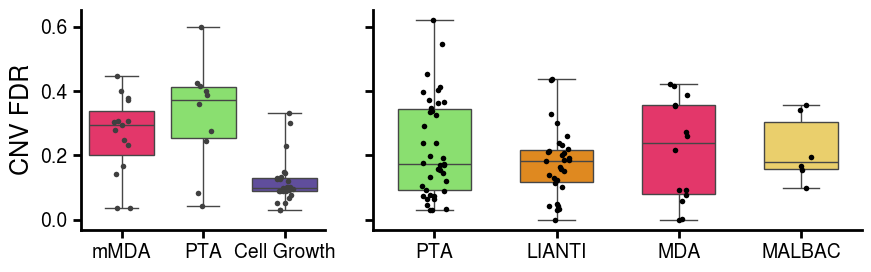

Fraction discordant bins per method:
              mean     std  median  count
wga_method                               
CapWGS      0.2029  0.1406  0.1448     50
DOP_PCR     0.2463  0.1852  0.3505      3
LIANTI      0.1773  0.1074  0.1840     30
MALBAC      0.2189  0.1059  0.1807      6
MDA         0.2146  0.1574  0.2383     14
PTA         0.2214  0.1526  0.1748     39

CapWGS sub-methods:
                        mean     std  median  count
amplification_method                               
Cell Growth           0.1184  0.0728  0.0983     25
PTA                   0.3235  0.1670  0.3729     10
mMDA                  0.2634  0.1229  0.2929     15


In [22]:
disc_full_frac = cells[["donor_id","sample_id","wga_method"]].merge(
    discord[["donor_id","sample_id","disc_frac_masked"]],
    on=["donor_id","sample_id"], how="left"
).dropna(subset=["disc_frac_masked"])

hsc4_bin = (disc_full_frac[disc_full_frac["donor_id"]=="HSC4"]
            .merge(cap[["barcode","amplification_method"]],
                   left_on="sample_id", right_on="barcode", how="left"))

fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios":[1, 2]}, sharey=True)

ax = axes[0]
sns.boxplot(data=hsc4_bin, x="amplification_method", y="disc_frac_masked", order=order_cap,
            ax=ax, hue="amplification_method", palette=pub_pal, whis=(0,100), width=0.8, legend=False)
sns.stripplot(data=hsc4_bin, x="amplification_method", y="disc_frac_masked", order=order_cap,
              ax=ax, size=4, color=".25")
ax.set_xlabel(""); ax.set_ylabel("CNV FDR", fontsize=18)
ax.tick_params(labelsize=14); sns.despine(ax=ax)

ax = axes[1]
disc_pub_frac = disc_full_frac[disc_full_frac["wga_method"].isin(order_pub)]
sns.boxplot(data=disc_pub_frac, x="wga_method", y="disc_frac_masked", order=order_pub,
            ax=ax, hue="wga_method", palette=pub_pal, whis=(0,100), width=0.6, legend=False)
sns.stripplot(data=disc_pub_frac, x="wga_method", y="disc_frac_masked", order=order_pub,
              ax=ax, size=4, color="black")
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=14); ax.tick_params(axis="y", labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(ROOT/"results/benchmarking/discordant_bins.png", bbox_inches="tight", dpi=600)
plt.show()

print("Fraction discordant bins per method:")
print(disc_full_frac.groupby("wga_method")["disc_frac_masked"].agg(["mean","std","median","count"]).round(4).to_string())
print()
print("CapWGS sub-methods:")
print(hsc4_bin.groupby("amplification_method")["disc_frac_masked"].agg(["mean","std","median","count"]).round(4).to_string())

In [25]:
disc_pub_frac.to_csv('../results/benchmarking/disc_pub_frac.csv')
hsc4_bin.to_csv('../results/benchmarking/hsc4_bin.csv')

## Metric 2 — Within-method pairwise MAPD (precision)

For every pair of cells sharing donor and WGA method, compute the median absolute difference between their smoothed log2 tracks (1Mb bins outside the bulk mask). This is the across-cell analogue of the PTA paper's MAPD: lower = more reproducible coverage shape across replicates of the same method.

CapWGS sub-method pairs use `amplification_method` (mMDA / PTA / Cell Growth) restricted to HSC4. The all-method panel pools donors but requires same-donor pairing within each method (avoids inter-donor coverage shape differences confounding the metric).

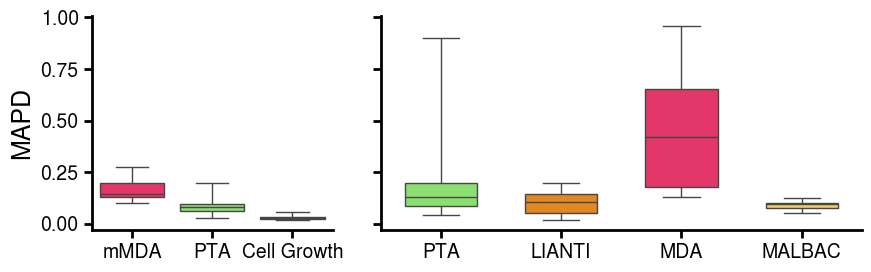

450 CapWGS sub-method pairs, 961 all-method pairs

CapWGS sub-methods:
              mean    std  median  count
method                                  
Cell Growth  0.029  0.008   0.027    300
PTA          0.095  0.052   0.082     45
mMDA         0.163  0.046   0.142    105

All methods:
         mean    std  median  count
method                             
LIANTI  0.100  0.049   0.104    435
MALBAC  0.090  0.023   0.094     15
MDA     0.435  0.248   0.422     60
PTA     0.198  0.197   0.129    451


In [23]:
# Pre-compute each cell's masked smooth log2 profile (Series indexed by seqnames + start_0).
profiles_masked = {}
for _, r in cells.iterrows():
    try:
        df = cell_smooth_log2(r["donor_id"], r["sample_id"])
    except FileNotFoundError:
        continue
    df = drop_masked(df, masks.get(r["donor_id"]), start_col="start_0", end_col="end")
    if len(df) < 100: continue
    profiles_masked[(r["donor_id"], r["sample_id"])] = df.set_index(["seqnames","start_0"])["smooth"]

cells_lbl = cells[["donor_id","sample_id","wga_method"]].merge(
    cap[["barcode","amplification_method"]], left_on="sample_id", right_on="barcode", how="left"
)

def mapd(a, b):
    return float(np.median(np.abs(a - b)))

def all_pairs(grp):
    keys = [(r["donor_id"], r["sample_id"]) for _, r in grp.iterrows()
            if (r["donor_id"], r["sample_id"]) in profiles_masked]
    out = []
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            ab = pd.concat([profiles_masked[keys[i]], profiles_masked[keys[j]]],
                           axis=1, join="inner").dropna()
            if len(ab) < 100: continue
            out.append(mapd(ab.iloc[:,0], ab.iloc[:,1]))
    return out

# Panel 1: CapWGS sub-methods (HSC4 only, labeled by amplification_method)
cap_rows = []
hsc4_lbl = cells_lbl[cells_lbl["donor_id"]=="HSC4"]
for method, grp in hsc4_lbl.groupby("amplification_method"):
    for v in all_pairs(grp):
        cap_rows.append({"method": method, "mapd": v})
cap_pair = pd.DataFrame(cap_rows)

# Panel 2: All methods (pairs within same donor + same wga_method)
pub_rows = []
for (method, donor), grp in cells_lbl.groupby(["wga_method","donor_id"]):
    if method not in order_pub: continue
    for v in all_pairs(grp):
        pub_rows.append({"method": method, "donor_id": donor, "mapd": v})
pub_pair = pd.DataFrame(pub_rows)

fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios":[1, 2]}, sharey=True)

ax = axes[0]
sns.boxplot(data=cap_pair, x="method", y="mapd", order=order_cap,
            ax=ax, hue="method", palette=pub_pal, whis=(0,100), width=0.8, legend=False)
# sns.stripplot(data=cap_pair, x="method", y="mapd", order=order_cap,
#               ax=ax, size=2, color=".25", alpha=0.5)
ax.set_xlabel(""); ax.set_ylabel("MAPD", fontsize=18)
ax.tick_params(labelsize=14); sns.despine(ax=ax)

ax = axes[1]
sns.boxplot(data=pub_pair, x="method", y="mapd", order=order_pub,
            ax=ax, hue="method", palette=pub_pal, whis=(0,100), width=0.6, legend=False)
# sns.stripplot(data=pub_pair, x="method", y="mapd", order=order_pub,
#               ax=ax, size=2, color="black", alpha=0.5)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=14); ax.tick_params(axis="y", labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(ROOT/"results/benchmarking/mapd.png", bbox_inches="tight", dpi=600)
plt.show()

print(f"{len(cap_pair)} CapWGS sub-method pairs, {len(pub_pair)} all-method pairs")
print()
print("CapWGS sub-methods:")
print(cap_pair.groupby("method")["mapd"].agg(["mean","std","median","count"]).round(3).to_string())
print()
print("All methods:")
print(pub_pair.groupby("method")["mapd"].agg(["mean","std","median","count"]).round(3).to_string())

In [24]:
cap_pair.to_csv('../results/benchmarking/cap_pair.csv')
pub_pair.to_csv('../results/benchmarking/pub_pair.csv')

## Bulk caller — TBD

AneuFinder is not appropriate for the full-depth bulks. Options for a paired-bulk "truth" set:

1. **Different caller for bulks**: CNVkit, GATK gCNV, or Control-FREEC on the bulk BAMs; intersect calls with per-cell AneuFinder segments to compute FP overlap.
2. **Downsample bulks to ~5–25M reads** before AneuFinder so the HMM is in its calibrated regime.
3. **PTA-paper strategy**: skip per-event matching; treat normal-tissue donors as diploid truth (what this notebook currently does) and report n_nondip + bp_nondip as FP burden.

Currently we run with #3.